# Time-dependent CRS (Plate tectonics!)

In [ ]:
import geopandas as gpd
import pandas as pd
import pyproj
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
def load_gnss_data(station):
     url = f'https://geodesy.unr.edu/gps_timeseries/IGS20/txyz/{station}.txyz2'
     df = pd.read_csv(
        url,
        names=['station_name', 'date', 'decimal_year', 'x', 'y', 'z', 'x_sigma', 'y_sigma', 'z_sigma', 'xy_corr', 'yz_corr', 'xz_corr', 'antenna_height'],
        sep=" "
    )
     return df

station = 'TMG2'
df = load_gnss_data(station)
df.head()

,station_name,date,decimal_year,x,y,z,x_sigma,y_sigma,z_sigma,xy_corr,yz_corr,xz_corr,antenna_height
0,TMG2,17DEC26,2017.9849,-1.283435e+06,-4.713072e+06,4.090105e+06,0.000824,0.002138,0.001802,0.550265,-0.812884,-0.502084,0.0083
1,TMG2,17DEC27,2017.9877,-1.283435e+06,-4.713072e+06,4.090105e+06,0.000821,0.002124,0.001813,0.538245,-0.812327,-0.489403,0.0083
2,TMG2,17DEC28,2017.9904,-1.283435e+06,-4.713072e+06,4.090105e+06,0.000841,0.002154,0.001820,0.561158,-0.812963,-0.507803,0.0083
3,TMG2,17DEC29,2017.9932,-1.283435e+06,-4.713072e+06,4.090105e+06,0.000833,0.002119,0.001768,0.562262,-0.806849,-0.511766,0.0083
4,TMG2,17DEC30,2017.9959,-1.283435e+06,-4.713072e+06,4.090105e+06,0.000831,0.002200,0.001849,0.544127,-0.815031,-0.502147,0.0083


In [ ]:
print('OBSERVED Translation:')
# NOTE: in 17 years we see motion on the order of 26cm
#observed_motion = construct_4d_point(df.iloc[[-1]]) - construct_4d_point(df.iloc[[0]])
df.loc[len(df)-1, ['x', 'y', 'z', 'decimal_year']] - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

OBSERVED Translation:


x              -0.115341
y               0.011505
z              -0.052978
decimal_year      7.8878
dtype: object

In [4]:
# +t_epoch 2015.0
itrf_2020_noam = '+proj=helmert +drx=0.000045 +dry=-0.000666 +drz=-0.000098 +convention=position_vector'
itrf_2020_noam_t = '+proj=helmert +dx=0.00037 +dy=0.00035 +dz=0.00074 +drx=0.000045 +dry=-0.000666 +drz=-0.000098 +convention=position_vector'

In [5]:
!echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch=2015.0

-1283434.98790067  -4713071.99288571  4090104.93462471     2025.8727


In [6]:
print('ESTIMATED Translation NOAM:')
predicted = !echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM +t_epoch=2015.0
np.fromstring(predicted[0], sep=' ') - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM:


x              -0.167936
y              -0.003072
z              -0.056236
decimal_year      7.8878
Name: 0, dtype: object

In [7]:
print('ESTIMATED Translation NOAM_T:')
predicted = !echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch=2015.0
np.fromstring(predicted[0], sep=' ') - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM_T:


x              -0.163913
y               0.000733
z              -0.048191
decimal_year      7.8878
Name: 0, dtype: object

In [8]:
# For case of translation it seems +inv is simply * -1
print('ESTIMATED Translation NOAM_T:')
predicted = !echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +inv +init=ITRF2020:NOAM_T +t_epoch=2015.0
np.fromstring(predicted[0], sep=' ') - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM_T:


x               0.163913
y              -0.000733
z               0.048191
decimal_year      7.8878
Name: 0, dtype: object

In [ ]:
# T_epoch is key! otherwise t_epoch =0 !
print('ESTIMATED Translation NOAM_T:')
predicted = !echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T
np.fromstring(predicted[0], sep=' ') - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM_T:


x              -30.541318
y                0.136665
z               -8.979201
decimal_year       7.8878
Name: 0, dtype: object

In [ ]:
print('ESTIMATED Translation NOAM_T:')
predicted = !echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch=0.0
np.fromstring(predicted[0], sep=' ') - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM_T:


x              -30.541318
y                0.136665
z               -8.979201
decimal_year       7.8878
Name: 0, dtype: object

In [ ]:
# Best for this case would be to use t_epoch = t0 (first observation date for this station)
print('ESTIMATED Translation NOAM_T:')
predicted_str = !echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch={df.iloc[0].decimal_year}
predicted = np.fromstring(predicted_str[0], sep=' ')
np.fromstring(predicted_str[0], sep=' ') - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM_T:


x              -0.118914
y               0.000532
z              -0.034961
decimal_year      7.8878
Name: 0, dtype: object

In [ ]:
# doing better!
print('OBSERVED Translation:')
# NOTE: in 17 years we see motion on the order of 26cm
#observed_motion = construct_4d_point(df.iloc[[-1]]) - construct_4d_point(df.iloc[[0]])
df.loc[len(df)-1, ['x', 'y', 'z', 'decimal_year']] - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

OBSERVED Translation:


x              -0.115341
y               0.011505
z              -0.052978
decimal_year      7.8878
dtype: object

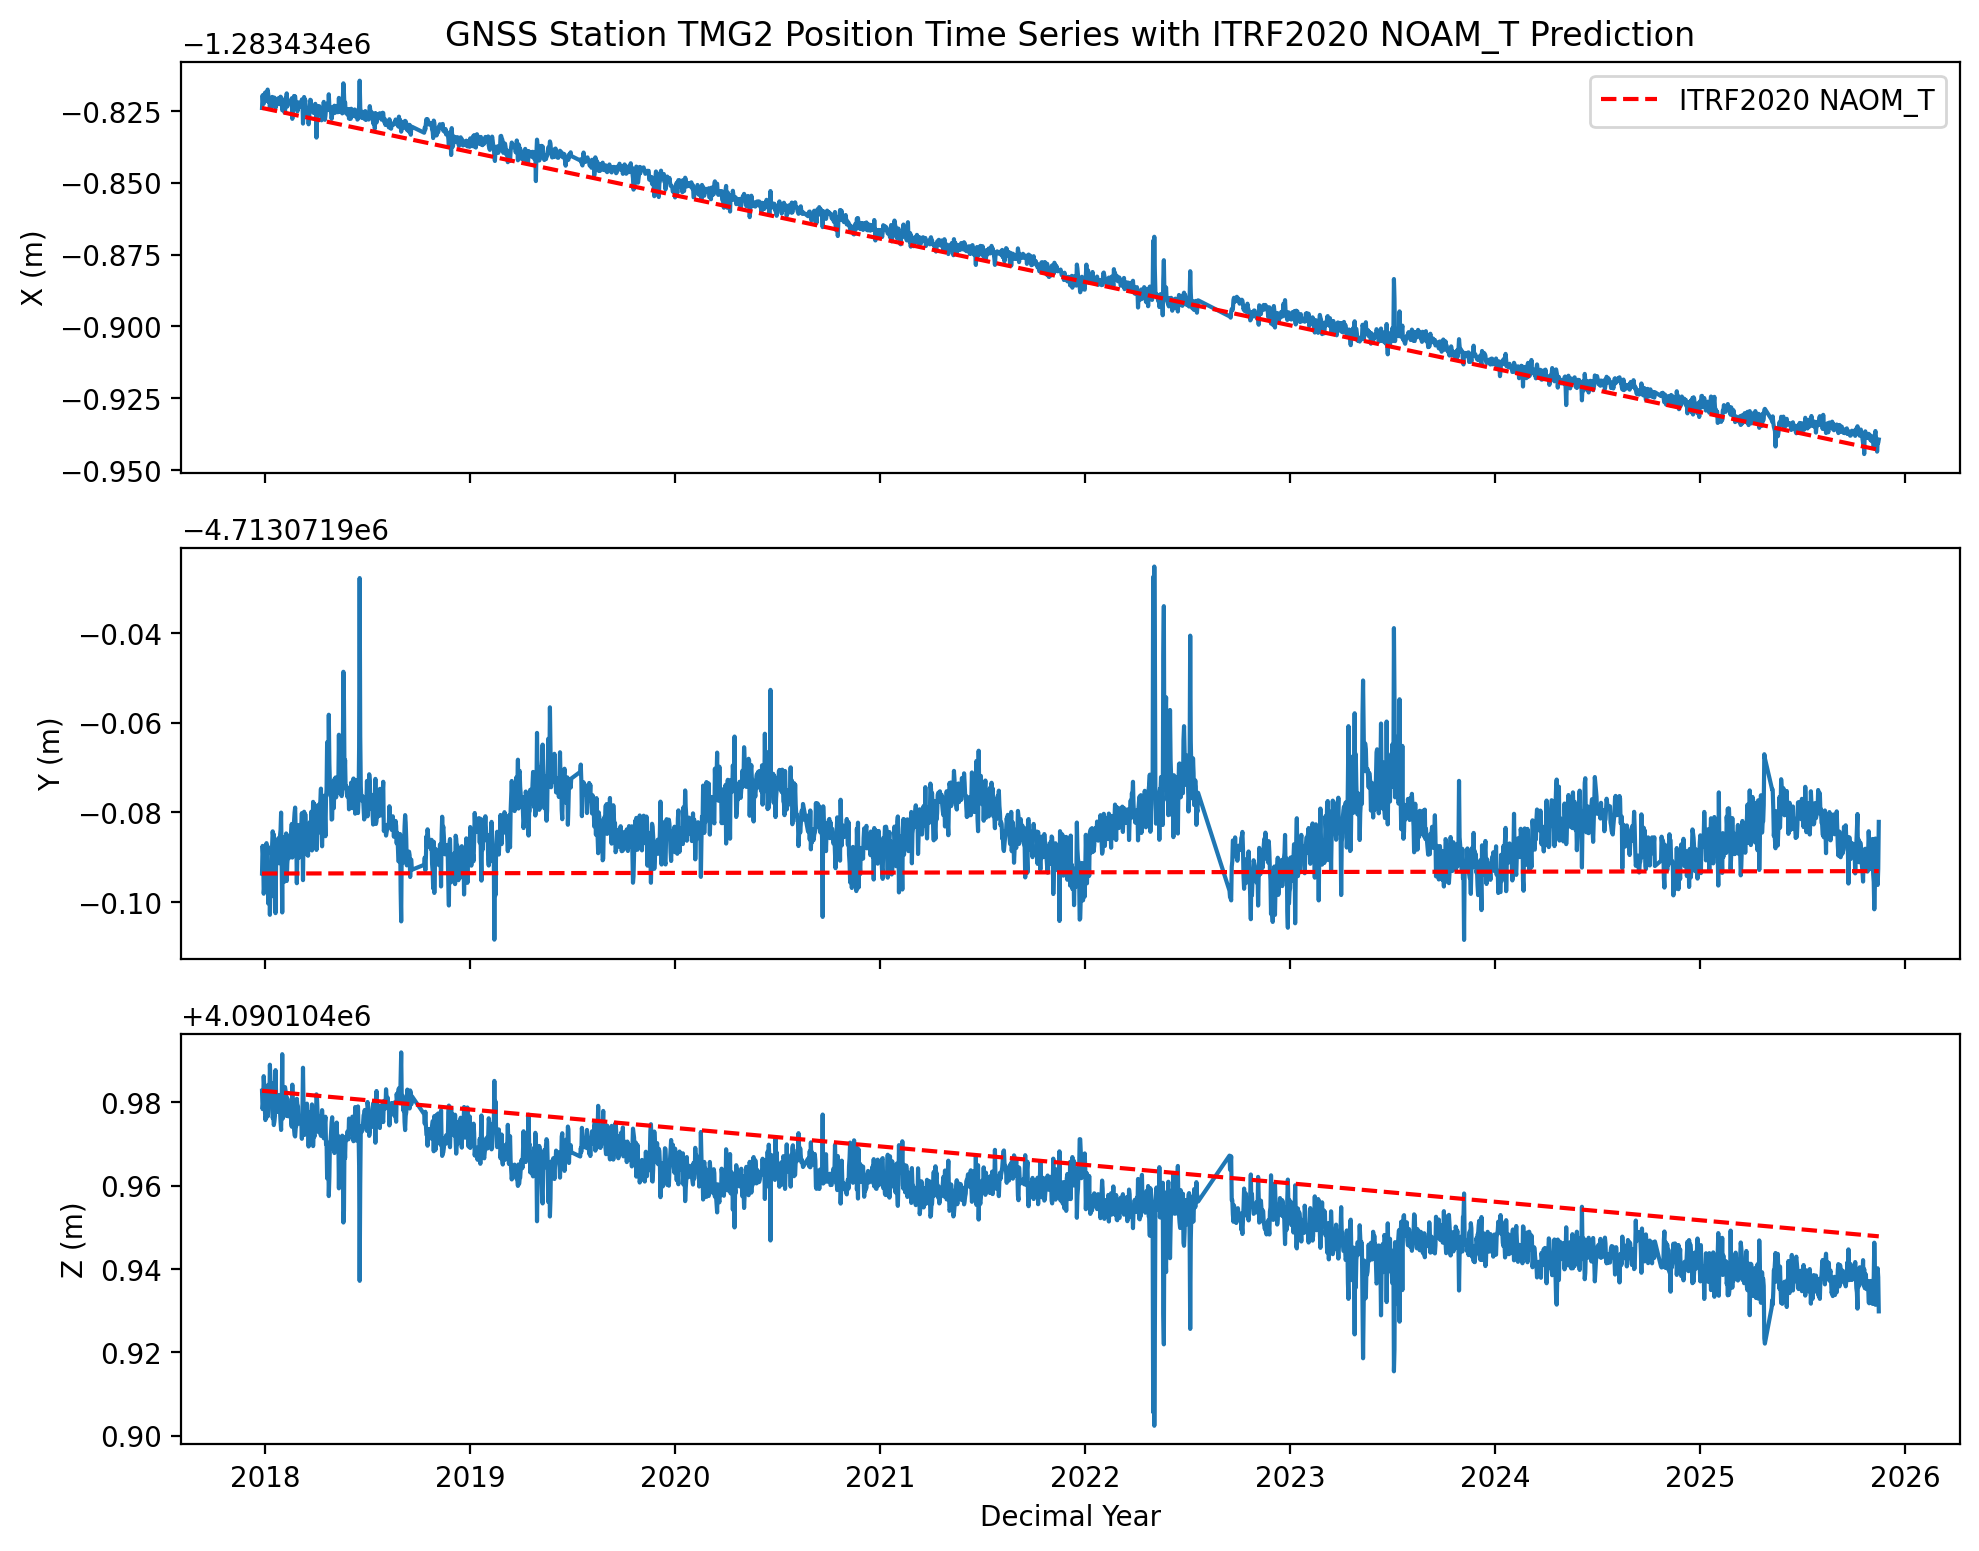

In [13]:
def plot_gnss_timeseries(df, station, predicted):

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    ax1.plot(df['decimal_year'], df['x'])
    ax1.plot([df['decimal_year'].iloc[0], predicted[-1]], [df['x'].iloc[0], predicted[0]], 'r--', label='ITRF2020 NAOM_T')
    ax1.set_ylabel('X (m)')
    ax1.legend()
    ax1.set_title(f'GNSS Station {station} Position Time Series with ITRF2020 NOAM_T Prediction')

    ax2.plot(df['decimal_year'], df['y'])
    ax2.plot([df['decimal_year'].iloc[0], predicted[-1]], [df['y'].iloc[0], predicted[1]], 'r--', label='ITRF2020 NAOM_T')
    ax2.set_ylabel('Y (m)')

    ax3.plot(df['decimal_year'], df['z'])
    ax3.plot([df['decimal_year'].iloc[0], predicted[-1]], [df['z'].iloc[0], predicted[2]], 'r--', label='ITRF2020 NAOM_T')
    ax3.set_ylabel('Z (m)')
    ax3.set_xlabel('Decimal Year')

    plt.tight_layout()

plot_gnss_timeseries(df, station, predicted)

In [ ]:
# Let's do the same for another station
#https://geodesy.unr.edu/NGLStationPages/stations/P804.sta
station = 'P804'
df = load_gnss_data(station)
df.head()

,station_name,date,decimal_year,x,y,z,x_sigma,y_sigma,z_sigma,xy_corr,yz_corr,xz_corr,antenna_height
0,P804,12OCT25,2012.8159,538950.034861,-5.329692e+06,3.450661e+06,0.001472,0.005157,0.003098,-0.409837,-0.861994,0.352077,0.0083
1,P804,12OCT26,2012.8186,538950.035262,-5.329692e+06,3.450661e+06,0.000860,0.002736,0.001732,-0.353988,-0.848338,0.323161,0.0083
2,P804,12OCT27,2012.8214,538950.033339,-5.329692e+06,3.450661e+06,0.000900,0.002926,0.001824,-0.423081,-0.859103,0.377863,0.0083
3,P804,12OCT28,2012.8241,538950.033401,-5.329692e+06,3.450661e+06,0.000833,0.002689,0.001702,-0.371730,-0.848445,0.335448,0.0083
4,P804,12OCT29,2012.8268,538950.035552,-5.329692e+06,3.450661e+06,0.000844,0.002631,0.001676,-0.388547,-0.844612,0.349343,0.0083


In [ ]:
print('OBSERVED Translation:')
# NOTE: in 17 years we see motion on the order of 26cm
#observed_motion = construct_4d_point(df.iloc[[-1]]) - construct_4d_point(df.iloc[[0]])
df.loc[len(df)-1, ['x', 'y', 'z', 'decimal_year']] - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

OBSERVED Translation:


x              -0.172801
y              -0.000447
z               0.011695
decimal_year     13.0568
dtype: object

In [ ]:
# Best for this case would be to use t_epoch = t0 (first observation date for this station)
print('ESTIMATED Translation NOAM_T:')
predicted_str = !echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch={df.iloc[0].decimal_year}
predicted = np.fromstring(predicted_str[0], sep=' ')
predicted - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM_T:


x              -0.173707
y              -0.008603
z               0.017201
decimal_year     13.0568
Name: 0, dtype: object

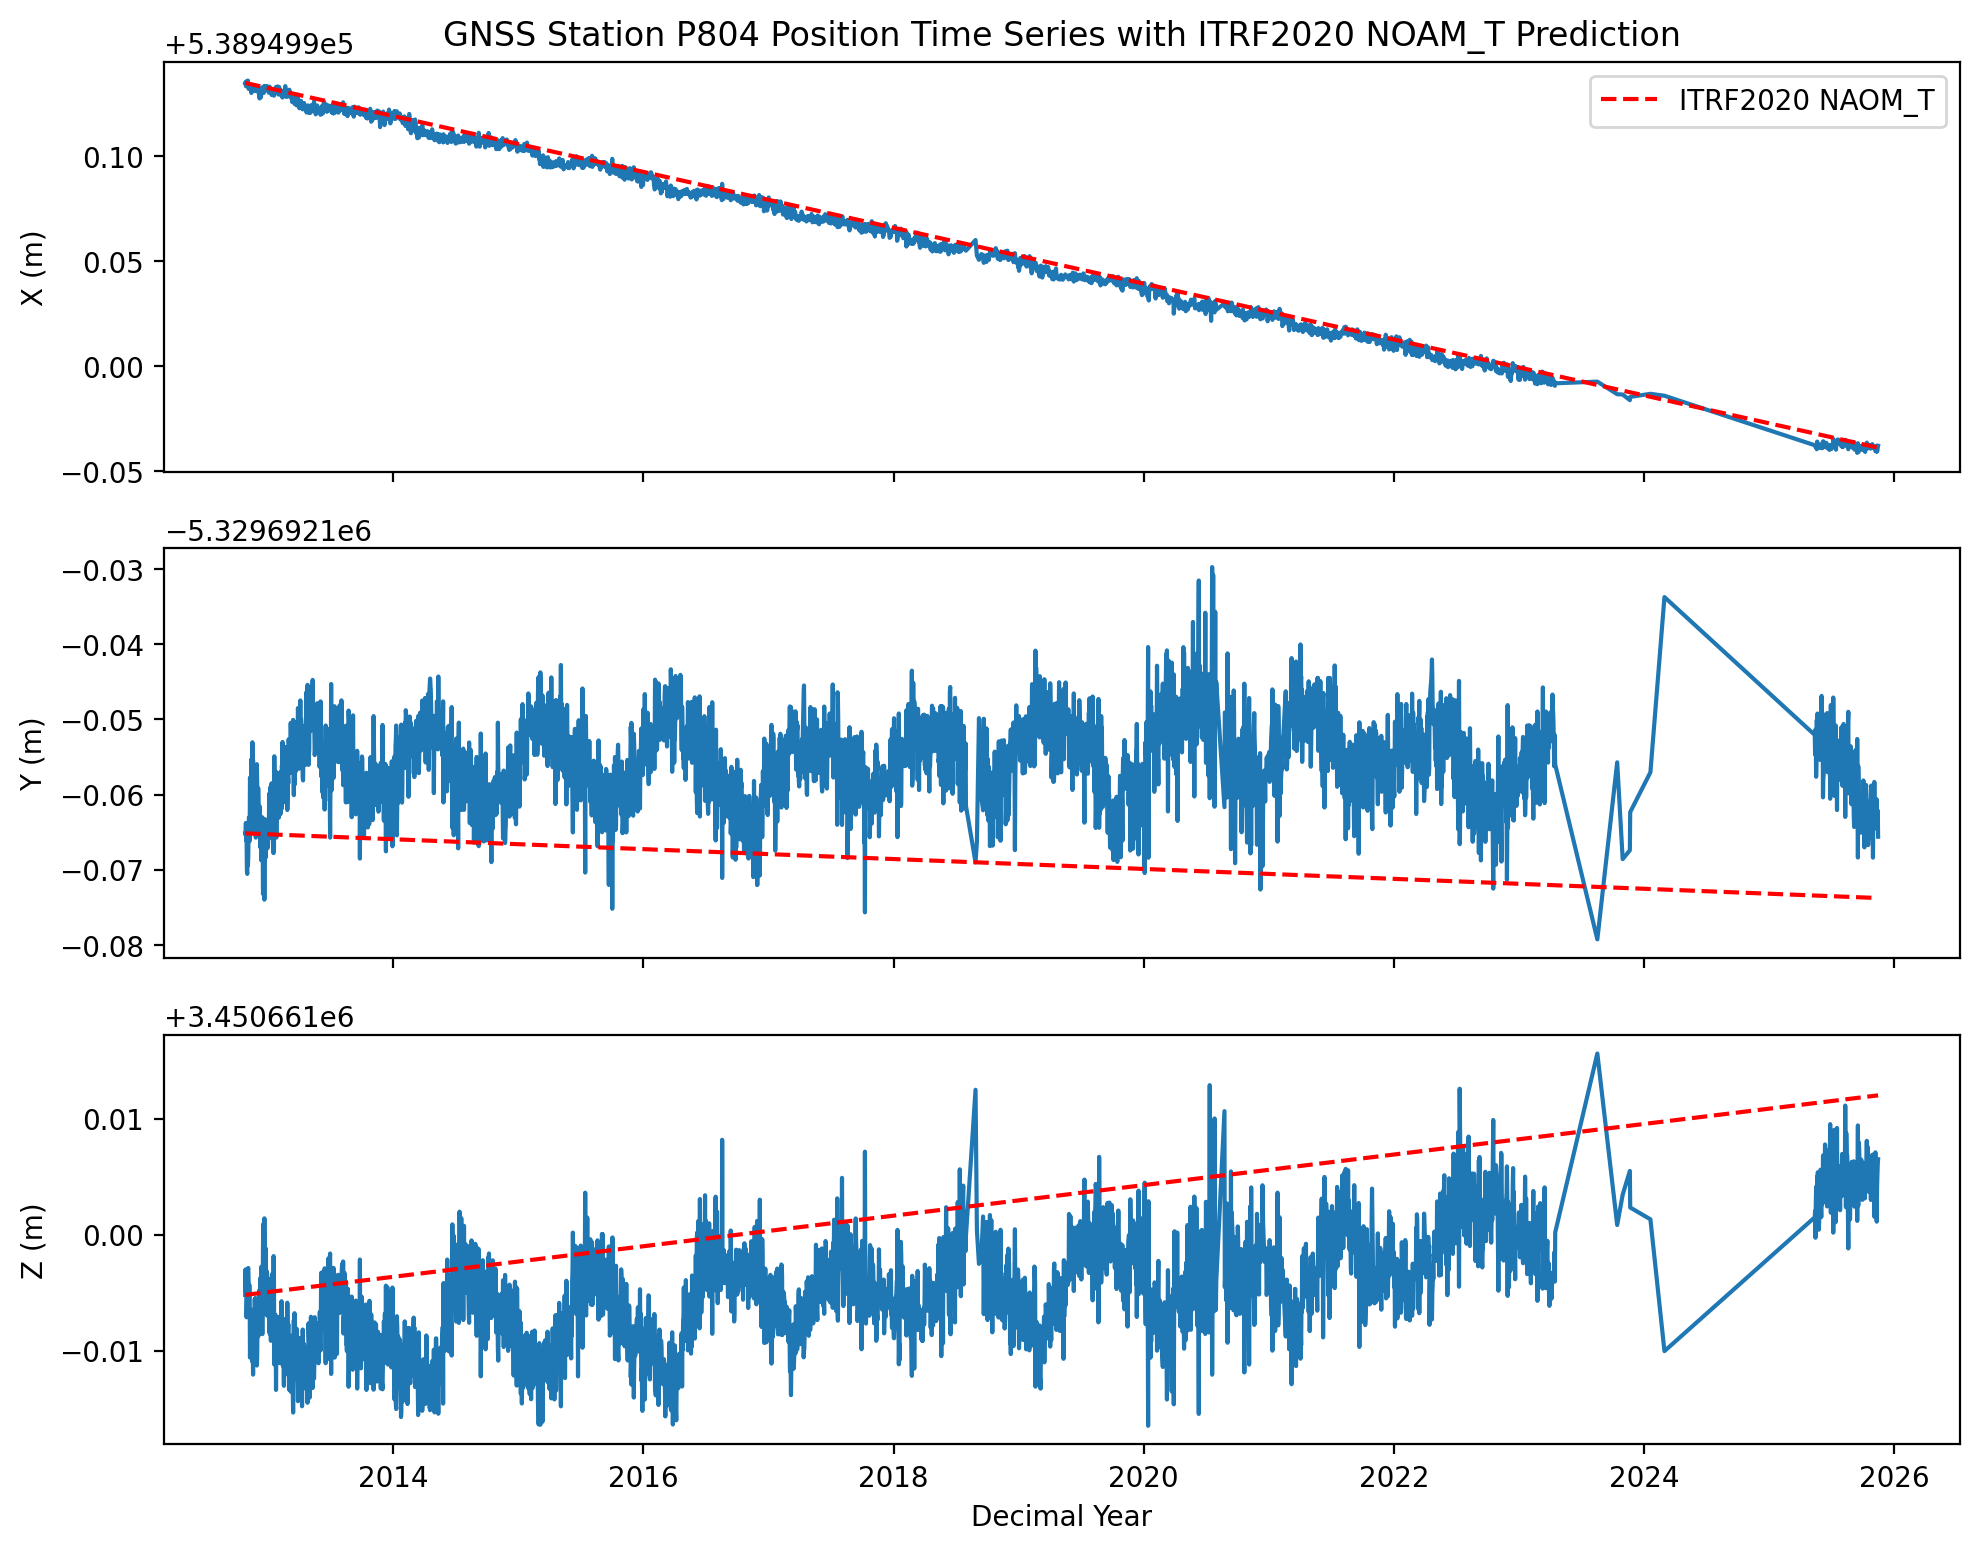

In [17]:
plot_gnss_timeseries(df, station, predicted)

In [ ]:
# Finall one more in NW (
# NOTE: expect worst perfomance here b/c model is *rigid* plate motion, no deformation
station = 'SEAT'
df = load_gnss_data(station)
df.head()

,station_name,date,decimal_year,x,y,z,x_sigma,y_sigma,z_sigma,xy_corr,yz_corr,xz_corr,antenna_height
0,SEAT,96JAN01,1996.0000,-2.300593e+06,-3.637847e+06,4.691079e+06,0.001670,0.002343,0.002795,0.791785,-0.796424,-0.716868,0.1149
1,SEAT,96JAN02,1996.0027,-2.300593e+06,-3.637847e+06,4.691079e+06,0.001557,0.002219,0.002708,0.782096,-0.786170,-0.694077,0.1149
2,SEAT,96JAN03,1996.0055,-2.300593e+06,-3.637847e+06,4.691079e+06,0.001586,0.002230,0.002699,0.783746,-0.785192,-0.704837,0.1149
3,SEAT,96JAN04,1996.0082,-2.300593e+06,-3.637847e+06,4.691079e+06,0.001597,0.002246,0.002699,0.785190,-0.787158,-0.709154,0.1149
4,SEAT,96JAN05,1996.0110,-2.300593e+06,-3.637847e+06,4.691079e+06,0.001552,0.002209,0.002688,0.776964,-0.787036,-0.702609,0.1149


In [ ]:
print('OBSERVED Translation:')
# NOTE: in 17 years we see motion on the order of 26cm
#observed_motion = construct_4d_point(df.iloc[[-1]]) - construct_4d_point(df.iloc[[0]])
df.loc[len(df)-1, ['x', 'y', 'z', 'decimal_year']] - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

OBSERVED Translation:


x              -0.336972
y               0.010516
z              -0.189063
decimal_year     29.8727
dtype: object

In [ ]:
# Best for this case would be to use t_epoch = t0 (first observation date for this station)
print('ESTIMATED Translation NOAM_T:')
predicted_str = !echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch={df.iloc[0].decimal_year}
predicted = np.fromstring(predicted_str[0], sep=' ')
predicted - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM_T:


x              -0.493056
y               0.012535
z              -0.223506
decimal_year     29.8727
Name: 0, dtype: object

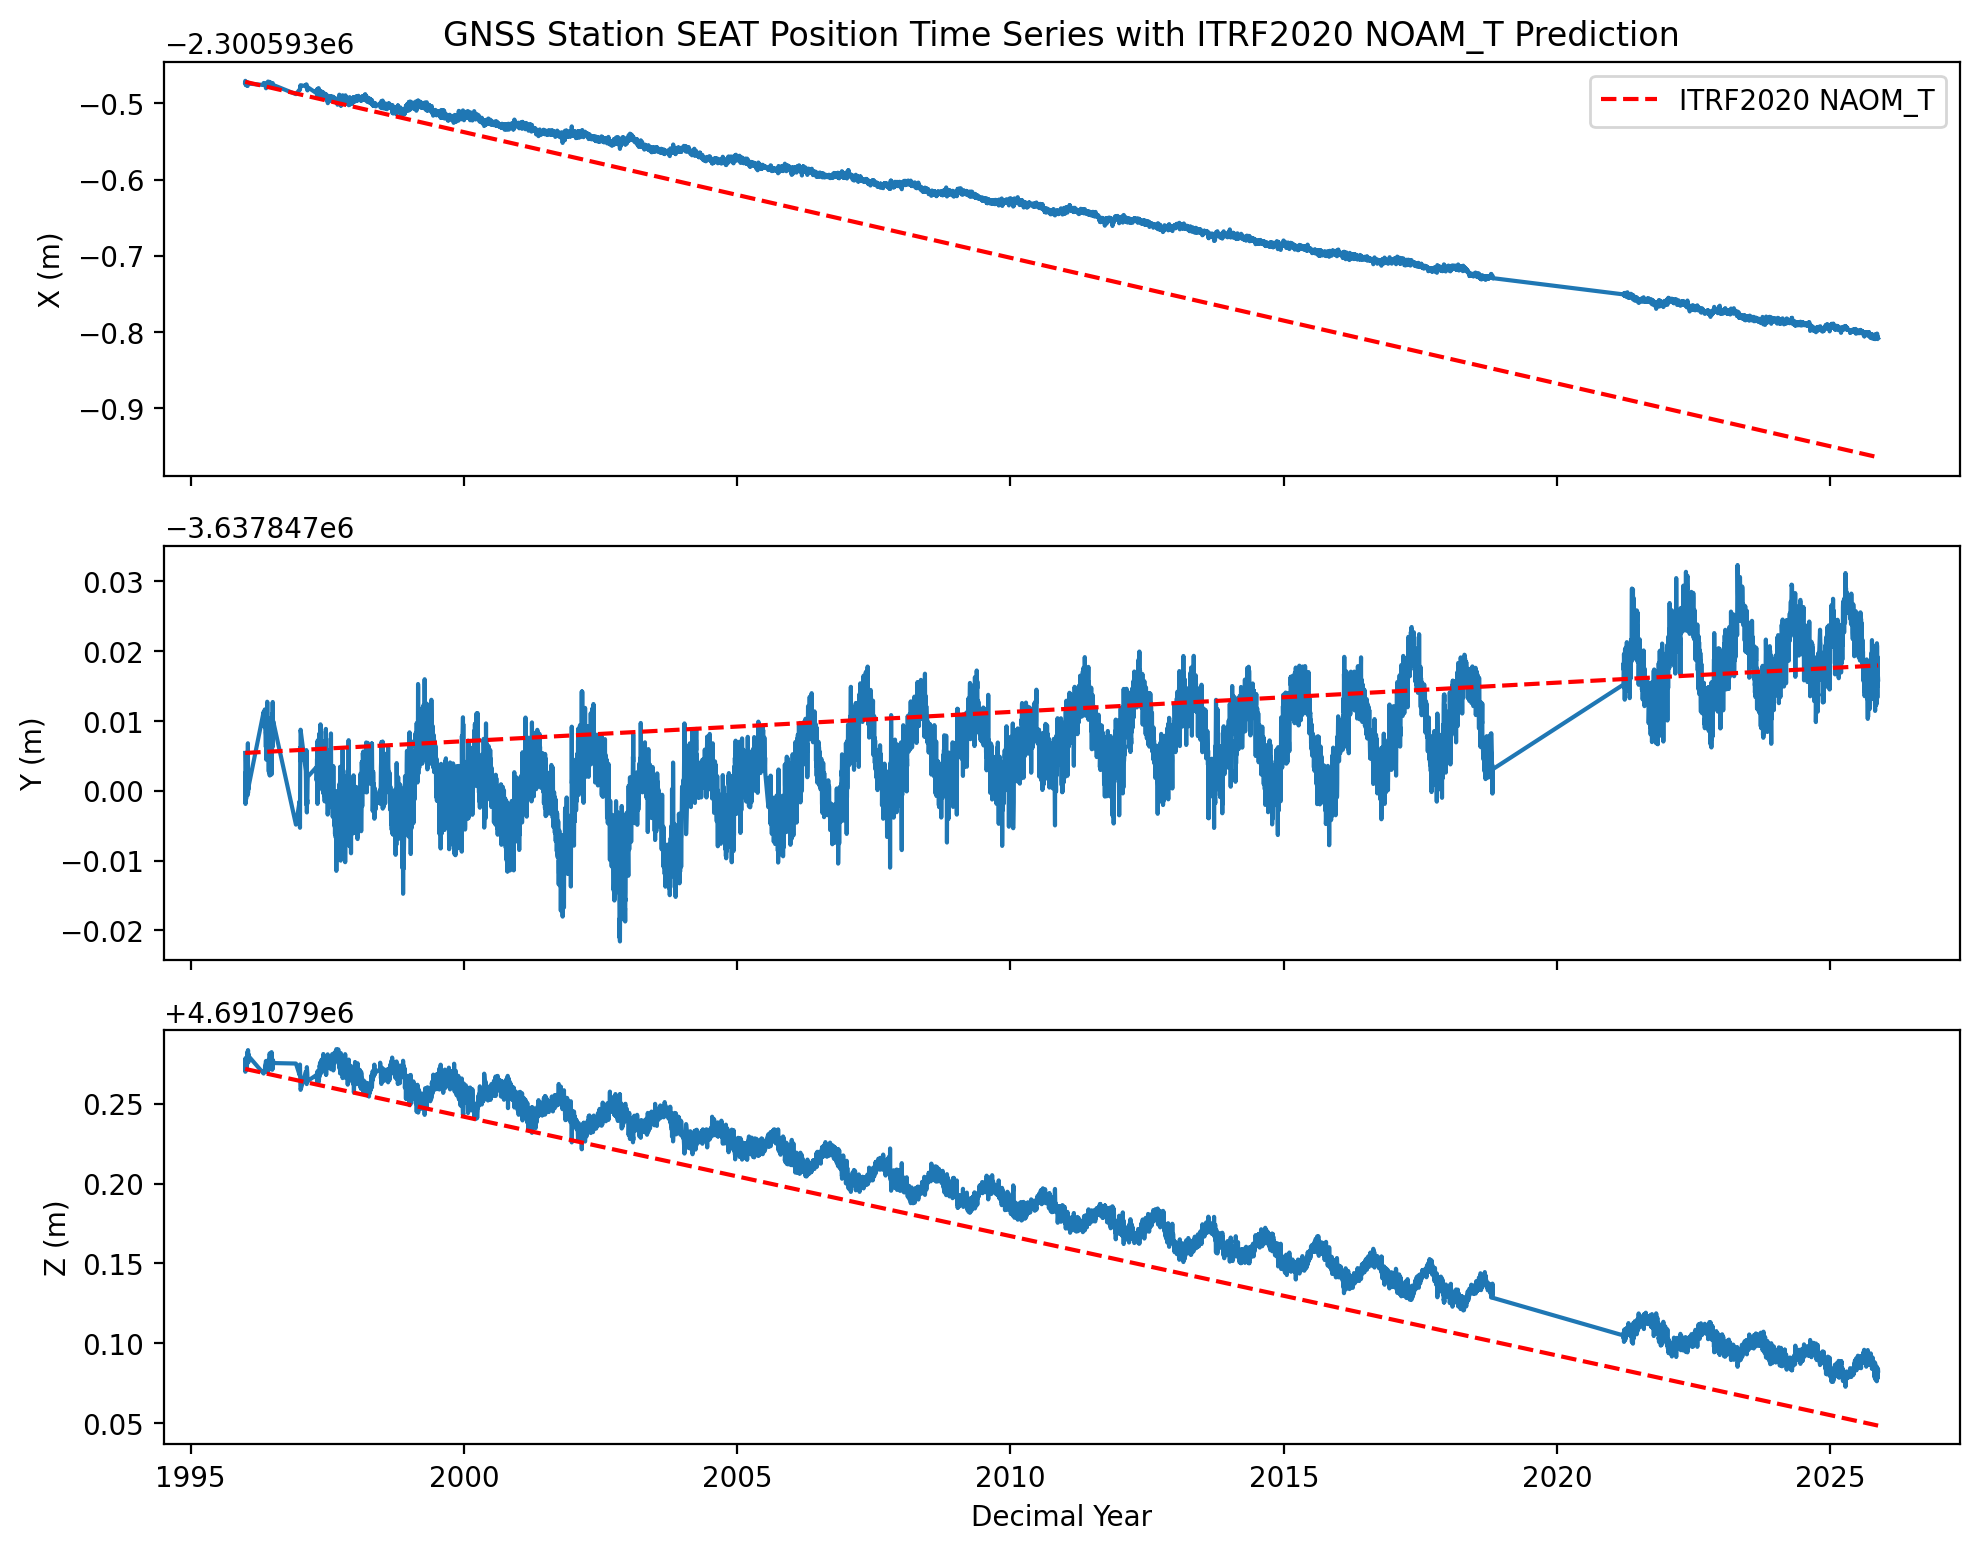

In [21]:
plot_gnss_timeseries(df, station, predicted)

### Colorado - Non ITRF station SE01

In [ ]:
# and another non-ITRF station (not part of best-fit solution, so also likely higher residuals
station = 'SE01'
df = load_gnss_data(station)
df.head()

,station_name,date,decimal_year,x,y,z,x_sigma,y_sigma,z_sigma,xy_corr,yz_corr,xz_corr,antenna_height
0,SE01,08SEP01,2008.6680,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001074,0.002424,0.002066,0.696277,-0.818696,-0.624849,-0.0855
1,SE01,08SEP02,2008.6708,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001008,0.002352,0.001916,0.657403,-0.820679,-0.589883,-0.0855
2,SE01,08SEP03,2008.6735,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001013,0.002299,0.001912,0.670161,-0.814316,-0.589007,-0.0855
3,SE01,08SEP04,2008.6762,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001049,0.002446,0.002006,0.678120,-0.807390,-0.606961,-0.0855
4,SE01,08SEP05,2008.6790,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001024,0.002285,0.001899,0.675431,-0.817738,-0.598166,-0.0855


In [ ]:
print('OBSERVED Translation:')
# NOTE: in 17 years we see motion on the order of 26cm
#observed_motion = construct_4d_point(df.iloc[[-1]]) - construct_4d_point(df.iloc[[0]])
df.loc[len(df)-1, ['x', 'y', 'z', 'decimal_year']] - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

OBSERVED Translation:


x              -0.262769
y               0.040102
z              -0.119795
decimal_year     17.2047
dtype: object

In [ ]:
# Best for this case would be to use t_epoch = t0 (first observation date for this station)
print('ESTIMATED Translation NOAM_T:')
predicted_str = !echo {df.iloc[0].x} {df.iloc[0].y} {df.iloc[0].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch={df.iloc[0].decimal_year}
predicted = np.fromstring(predicted_str[0], sep=' ')
predicted - df.loc[0, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM_T:


x               -0.25594
y               0.002844
z              -0.086119
decimal_year     17.2047
Name: 0, dtype: object

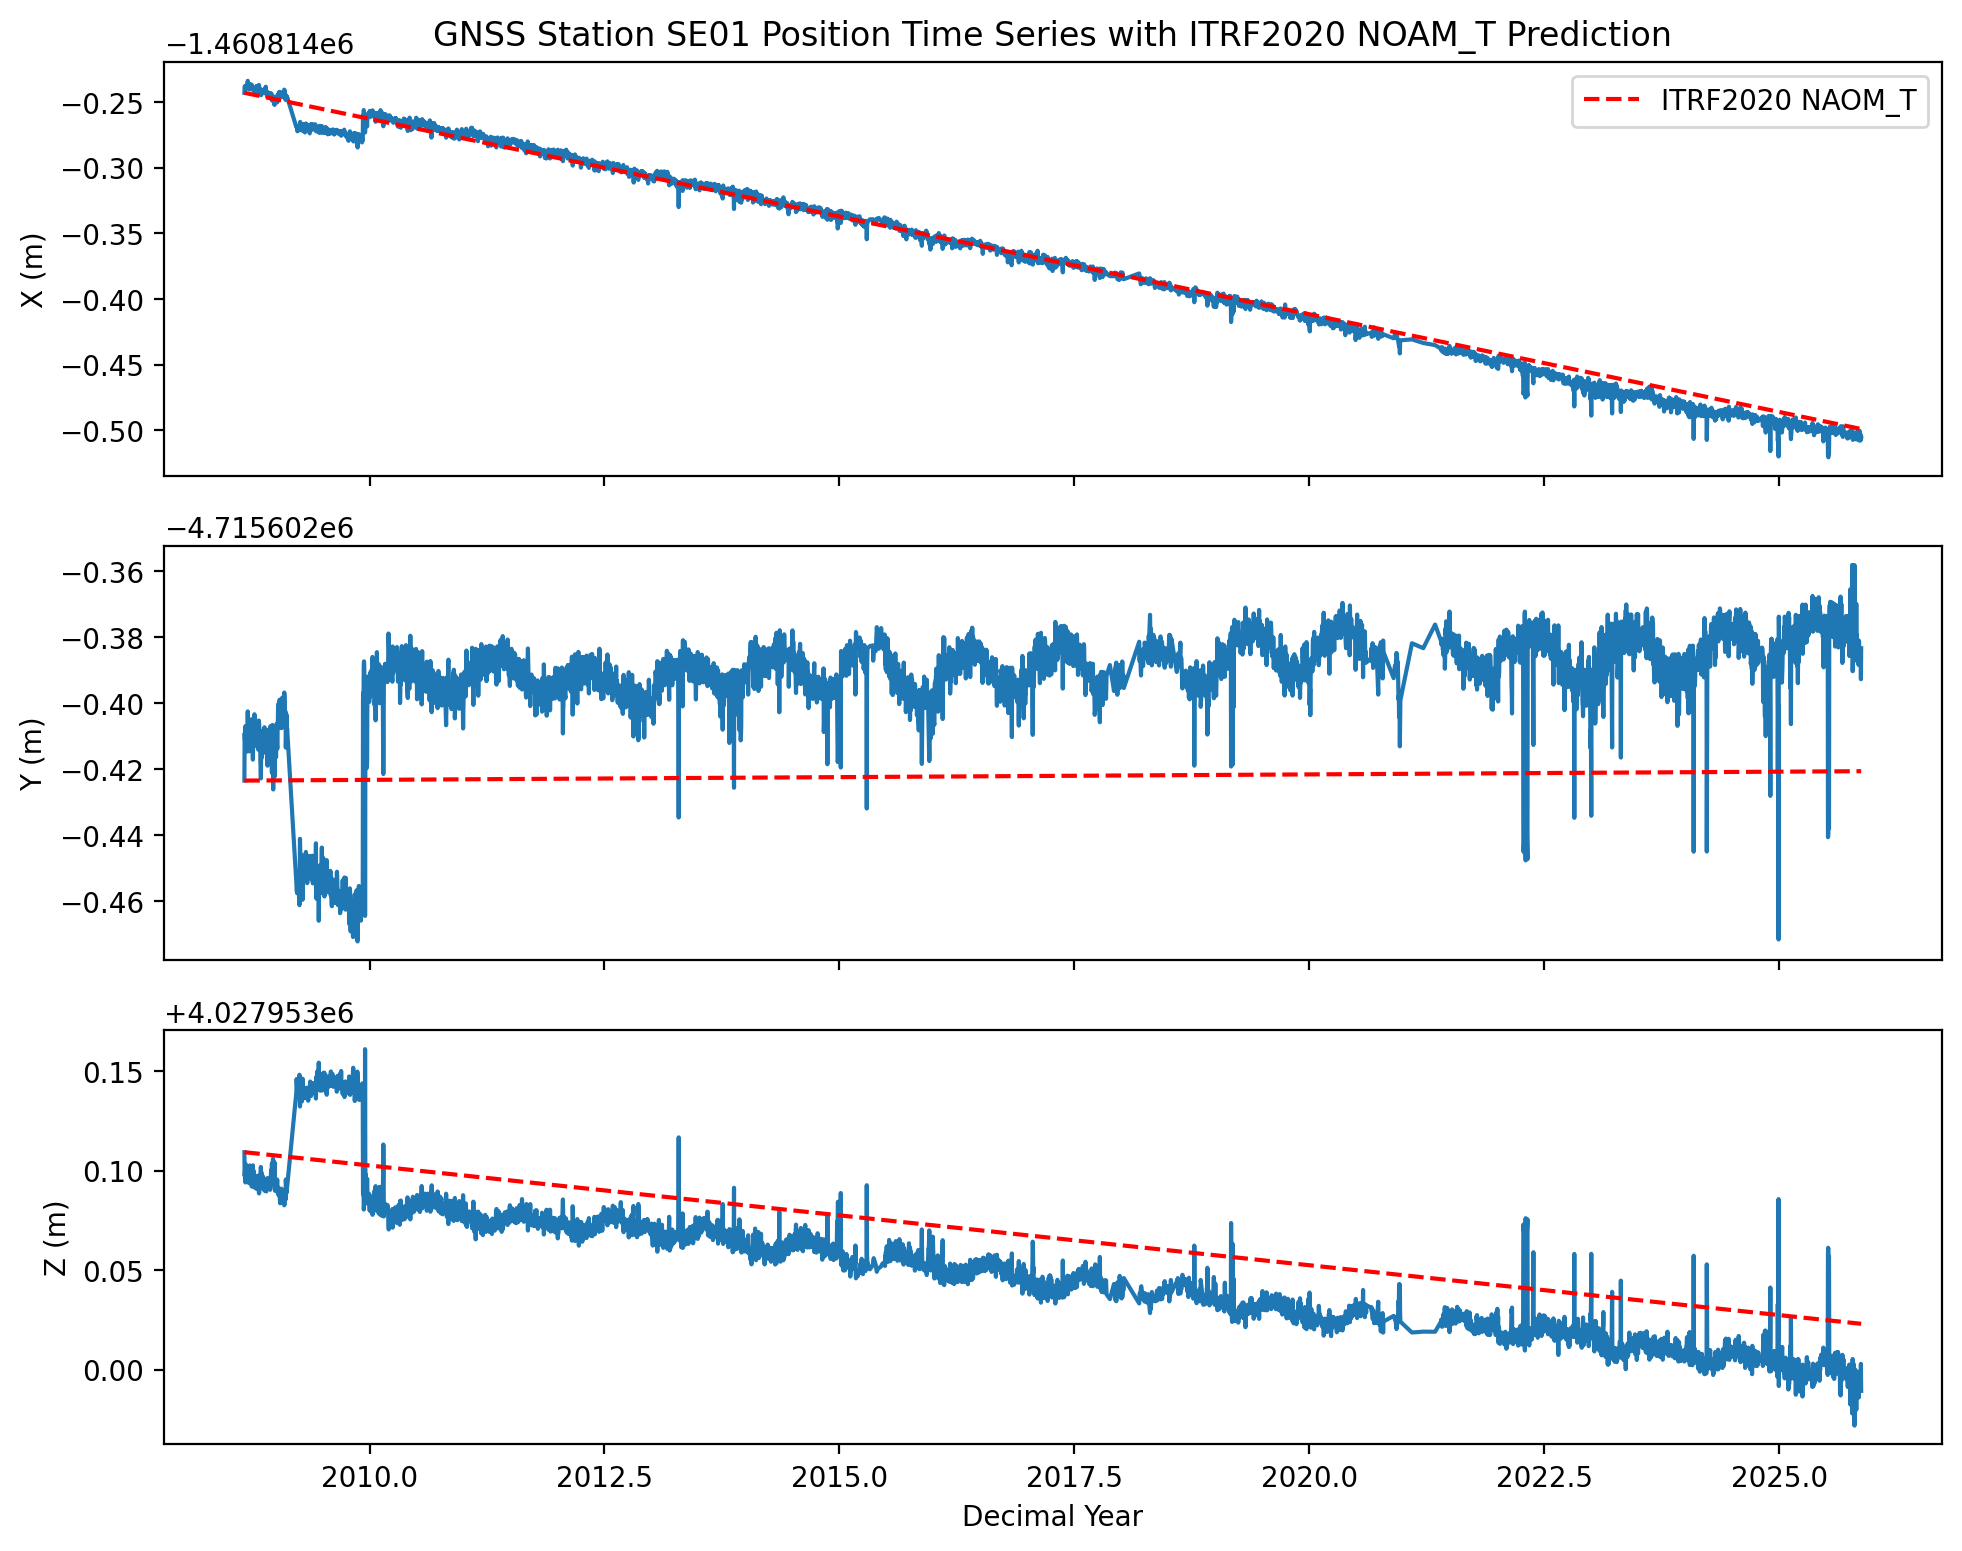

In [43]:
plot_gnss_timeseries(df, station, predicted)

In [132]:
# TEST: same point forward in time, different date ordering

# 1. put target date as part of input coordinate
!echo -1460814.24311725 -4715602.42353855 4027953.10920508 2025.8727 | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch=2008.668
#!echo -1460814.24311725 -4715602.42353855 4027953.10920508 2008.668 | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch=2025.8727

# 2. put target date as t_epoch
# +inv is a bit confusing here,  but this is a forward-in-time rigid plate motion transform
!echo -1460814.24311725 -4715602.42353855 4027953.10920508 2008.668 | cct -d 8 +proj=pipeline +step +inv +init=ITRF2020:NOAM_T +t_epoch=2025.8727 +step +proj=set +v_4=2025.8727

-1460814.49905708  -4715602.42069470  4027953.02308612     2025.8727
-1460814.49905708  -4715602.42069470  4027953.02308613     2025.8727


In [ ]:
# TEST: backward in time

# 1. target date in t_epoch (again, need +inv) b/c transform defined wrt t_obs
!echo -1460814.505886 -4715602.383437 4027952.98941 2025.8727 | cct -d 8 +proj=pipeline +step +inv +init=ITRF2020:NOAM_T +t_epoch=2008.668 +step +proj=set +v_4=2008.668

# 2. target date as input coordinate
!echo -1460814.505886 -4715602.383437 4027952.98941 2008.668 | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch=2025.8727

-1460814.24994617  -4715602.38628086  4027953.07552897     2008.6680
-1460814.24994617  -4715602.38628086  4027953.07552897     2008.6680


In [ ]:
# Round trip transform test (Preferred b/c observation position and time kept together)
p0 = '-1460814.24311725 -4715602.42353855 4027953.10920508 2008.668'
print(p0)
predicted = !echo {p0} | cct -d 8 +proj=pipeline +step +inv +init=ITRF2020:NOAM_T +t_epoch=2025.8727 +step +proj=set +v_4=2025.8727
print(predicted[0])
round_trip = !echo {predicted[0]} | cct -d 8 +proj=pipeline +step +inv +init=ITRF2020:NOAM_T +t_epoch=2008.668 +step +proj=set +v_4=2008.668
print(round_trip[0])

-1460814.24311725 -4715602.42353855 4027953.10920508 2008.668
-1460814.49905708  -4715602.42069470  4027953.02308613     2025.8727
-1460814.24311725  -4715602.42353856  4027953.10920510     2008.6680


In [ ]:
# SO in summary, less intuitive, but less verbose to put target date as t_obs :)
p0 = '-1460814.24311725 -4715602.42353855 4027953.10920508 2025.8727' # 'trick
print(p0)
predicted = !echo {p0} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch=2008.668
# THis get's messy & confusing having to swap dates around!
round_trip = !echo {predicted[0].replace('2025.8727', '2008.668')} | cct -d 8 +proj=pipeline +step +init=ITRF2020:NOAM_T +t_epoch=2025.8727
print(round_trip[0])

-1460814.24311725 -4715602.42353855 4027953.10920508 2025.8727
-1460814.24311725  -4715602.42353856  4027953.10920509     2008.6680


## Back in time!

In [ ]:
print('OBSERVED Translation:')
# NOTE: in 17 years we see motion on the order of 26cm
#observed_motion = construct_4d_point(df.iloc[[-1]]) - construct_4d_point(df.iloc[[0]])
df.loc[0, ['x', 'y', 'z', 'decimal_year']] - df.loc[len(df)-1, ['x', 'y', 'z', 'decimal_year']]

OBSERVED Translation:


x               0.262769
y              -0.040102
z               0.119795
decimal_year    -17.2047
dtype: object

In [ ]:
# Going in the opposite direction
# Best for this case would be to use t_epoch = t0 (first observation date for this station)
print('ESTIMATED Translation NOAM_T:')

target_year = df.iloc[0].decimal_year

predicted_str = !echo {df.iloc[-1].x} {df.iloc[-1].y} {df.iloc[-1].z} {df.iloc[-1].decimal_year} | cct -d 8 +proj=pipeline +step +inv +init=ITRF2020:NOAM_T +t_epoch={target_year} +step +proj=set +v_4={target_year}


# NOTE: this does nothing since t_epoch = t_obs (so no translation!)
#predicted_str = !echo {df.iloc[-1].x} {df.iloc[-1].y} {df.iloc[-1].z} 0 | cct -d 8 +proj=pipeline +step +inv +init=ITRF2020:NOAM_T +t_epoch=0

predicted = np.fromstring(predicted_str[0], sep=' ')
# Residual between observed and predicted (not very meaningul since any individual point can have noise)
#df.loc[0, ['x', 'y', 'z', 'decimal_year']] - predicted

# Predicted Translation between original and predicted positions
predicted - df.loc[len(df)-1, ['x', 'y', 'z', 'decimal_year']]

ESTIMATED Translation NOAM_T:


x                0.25594
y              -0.002844
z               0.086119
decimal_year    -17.2047
Name: 5611, dtype: object

In [ ]:
# NOTE: not exactly the same b/c any individual point has noise!

# Summary: we've figured out how to 'move' points in time. might be useful to compare altimeter measurements to DEMs
## NOTE: even in 10 years we have 10cm vertical difference in position

What does PROJ do if we have a position in ITRF2014 that we move to ITRF2020@epoch?


In [145]:
# well defined at t=2015
!projinfo -s ITRF2014 -t ITRF2020 -o proj

Candidate operations found: 1
-------------------------------------
Operation No. 1:

unknown id, Conversion from ITRF2014 (geog2D) to ITRF2014 (geocentric) + ITRF2014 to ITRF2020 (1) + Conversion from ITRF2020 (geocentric) to ITRF2020 (geog2D), 0.001 m, World, time-dependent operation

PROJ string:
+proj=pipeline
  +step +proj=axisswap +order=2,1
  +step +proj=unitconvert +xy_in=deg +xy_out=rad
  +step +proj=cart +ellps=GRS80
  +step +proj=helmert +x=0.0014 +y=0.0009 +z=-0.0014 +rx=0 +ry=0 +rz=0 +s=0.00042
        +dx=0 +dy=0.0001 +dz=-0.0002 +drx=0 +dry=0 +drz=0 +ds=0 +t_epoch=2015
        +convention=position_vector
  +step +inv +proj=cart +ellps=GRS80
  +step +proj=unitconvert +xy_in=rad +xy_out=deg
  +step +proj=axisswap +order=2,1


In [ ]:
# # simplify by stating in ECEF coords - just the helmert!
!projinfo -s EPSG:7789 -t EPSG:9988 -o proj

Candidate operations found: 1
-------------------------------------
Operation No. 1:

EPSG:9991, ITRF2014 to ITRF2020 (1), 0.001 m, World., time-dependent operation

PROJ string:
+proj=helmert +x=0.0014 +y=0.0009 +z=-0.0014 +rx=0 +ry=0 +rz=0 +s=0.00042 +dx=0
      +dy=0.0001 +dz=-0.0002 +drx=0 +dry=0 +drz=0 +ds=0 +t_epoch=2015
      +convention=position_vector


In [ ]:
# # simplify by stating in ECEF coords - just the helmert!
#!projinfo -s EPSG:7789 -t EPSG:9988@2025.0 -o proj # does not work
#!projinfo -s EPSG:7789 -t EPSG:9988 --t_epoch 2025.0 -o proj
#!projinfo -s EPSG:7789 --s_epoch 2010.0  -t EPSG:9988 --t_epoch 2025.0 -o proj
#!projinfo -s ITRF2014@2010.0 -t ITRF2020@2025.0 -o proj note: helmert unchanged, only setting of epochs


Candidate operations found: 1
-------------------------------------
Operation No. 1:

EPSG:9991, ITRF2014 to ITRF2020 (1), 0.001 m, World.

PROJ string:
+proj=helmert +x=0.0014 +y=0.0009 +z=-0.0014 +rx=0 +ry=0 +rz=0 +s=0.00042 +dx=0
      +dy=0.0001 +dz=-0.0002 +drx=0 +dry=0 +drz=0 +ds=0 +t_epoch=2015
      +convention=position_vector


In [ ]:
# Can still get ITRF2014 solutions here: https://geodesy.unr.edu/gps_timeseries/IGS14/txyz/IGS14/
# and another non-ITRF station (not part of best-fit solution, so also likely higher residuals

def load_gnss_data_2014(station):
     url = f'https://geodesy.unr.edu/gps_timeseries/IGS14/txyz/IGS14/{station}.txyz2'
     df = pd.read_csv(
        url,
        names=['station_name', 'date', 'decimal_year', 'x', 'y', 'z', 'x_sigma', 'y_sigma', 'z_sigma', 'xy_corr', 'yz_corr', 'xz_corr', 'antenna_height'],
        sep=" "
    )
     return df

station = 'SE01'
df14 = load_gnss_data_2014(station)
df14.set_index(pd.to_datetime(df14.date, format="%y%b%d"), inplace=True)

In [164]:
df14.head()

,station_name,date,decimal_year,x,y,z,x_sigma,y_sigma,z_sigma,xy_corr,yz_corr,xz_corr,antenna_height
date,,,,,,,,,,,,,
2009-12-06,SE01,09DEC06,2009.9302,-1.460814e+06,-4.715602e+06,4.027953e+06,0.000864,0.001938,0.001613,0.619732,-0.797477,-0.540820,0.0
2009-12-07,SE01,09DEC07,2009.9329,-1.460814e+06,-4.715602e+06,4.027953e+06,0.000869,0.001950,0.001616,0.616629,-0.797545,-0.541546,0.0
2009-12-08,SE01,09DEC08,2009.9357,-1.460814e+06,-4.715602e+06,4.027953e+06,0.000883,0.001970,0.001626,0.628405,-0.799655,-0.551830,0.0
2009-12-09,SE01,09DEC09,2009.9384,-1.460814e+06,-4.715602e+06,4.027953e+06,0.000877,0.001976,0.001654,0.604989,-0.799382,-0.539738,0.0
2009-12-10,SE01,09DEC10,2009.9411,-1.460814e+06,-4.715602e+06,4.027953e+06,0.000878,0.001955,0.001634,0.626320,-0.795521,-0.544755,0.0


In [165]:
# Huh, further back in time?
df.set_index(pd.to_datetime(df.date, format="%y%b%d"), inplace=True)
df.head()

,station_name,date,decimal_year,x,y,z,x_sigma,y_sigma,z_sigma,xy_corr,yz_corr,xz_corr,antenna_height
date,,,,,,,,,,,,,
2008-09-01,SE01,08SEP01,2008.6680,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001074,0.002424,0.002066,0.696277,-0.818696,-0.624849,-0.0855
2008-09-02,SE01,08SEP02,2008.6708,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001008,0.002352,0.001916,0.657403,-0.820679,-0.589883,-0.0855
2008-09-03,SE01,08SEP03,2008.6735,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001013,0.002299,0.001912,0.670161,-0.814316,-0.589007,-0.0855
2008-09-04,SE01,08SEP04,2008.6762,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001049,0.002446,0.002006,0.678120,-0.807390,-0.606961,-0.0855
2008-09-05,SE01,08SEP05,2008.6790,-1.460814e+06,-4.715602e+06,4.027953e+06,0.001024,0.002285,0.001899,0.675431,-0.817738,-0.598166,-0.0855


In [189]:
# Join df and df14, keeping only decimal_year, x, y, z columns
df_merged = pd.concat([
    df[['decimal_year', 'x', 'y', 'z']].add_suffix('_2020'),
    df14[['decimal_year', 'x', 'y', 'z']].add_suffix('_2014')
], axis=1)

df_merged = df_merged.dropna()  # keep only common dates
df_merged.head()

,decimal_year_2020,x_2020,y_2020,z_2020,decimal_year_2014,x_2014,y_2014,z_2014
date,,,,,,,,
2009-12-06,2009.9302,-1.460814e+06,-4.715602e+06,4.027953e+06,2009.9302,-1.460814e+06,-4.715602e+06,4.027953e+06
2009-12-07,2009.9329,-1.460814e+06,-4.715602e+06,4.027953e+06,2009.9329,-1.460814e+06,-4.715602e+06,4.027953e+06
2009-12-08,2009.9357,-1.460814e+06,-4.715602e+06,4.027953e+06,2009.9357,-1.460814e+06,-4.715602e+06,4.027953e+06
2009-12-09,2009.9384,-1.460814e+06,-4.715602e+06,4.027953e+06,2009.9384,-1.460814e+06,-4.715602e+06,4.027953e+06
2009-12-10,2009.9411,-1.460814e+06,-4.715602e+06,4.027953e+06,2009.9411,-1.460814e+06,-4.715602e+06,4.027953e+06


<Axes: xlabel='date'>

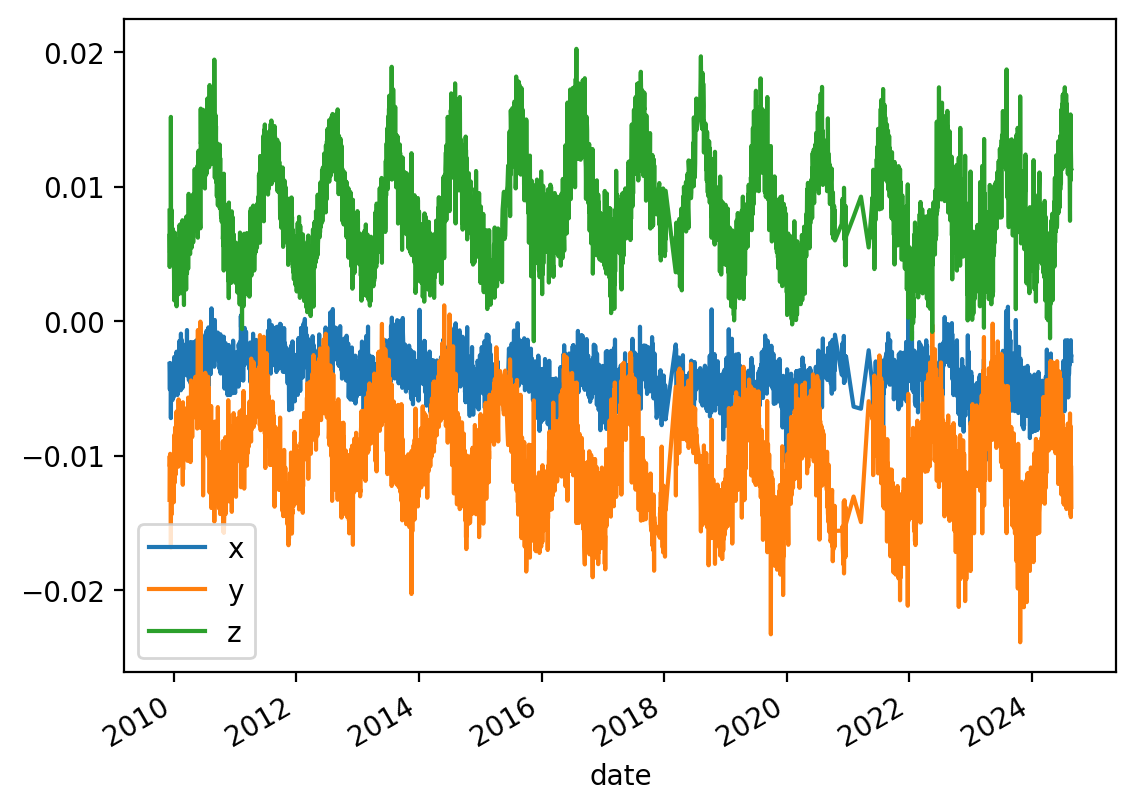

In [ ]:
# Huh, why the seasonal differences here... in any cas very small (~mm)
cols = ['x', 'y', 'z']
(df[cols] - df14[cols]).plot()

In [175]:
pipeline = !projinfo -s EPSG:7789 -t EPSG:9988 -o proj --single-line -q
pipeline[0]

'+proj=helmert +x=0.0014 +y=0.0009 +z=-0.0014 +rx=0 +ry=0 +rz=0 +s=0.00042 +dx=0 +dy=0.0001 +dz=-0.0002 +drx=0 +dry=0 +drz=0 +ds=0 +t_epoch=2015 +convention=position_vector'

In [ ]:
# P0 ITRF2014
!echo {df_merged.iloc[0].x_2014} {df_merged.iloc[0].y_2014} {df_merged.iloc[0].z_2014} {df_merged.iloc[0].decimal_year_2014}

-1460814.25703231 -4715602.38542501 4027953.08029279 2009.9302


In [ ]:
# P0 ITRF2020  # difference on order <1cm
!echo {df_merged.iloc[0].x_2020} {df_merged.iloc[0].y_2020} {df_merged.iloc[0].z_2020} {df_merged.iloc[0].decimal_year_2020}

-1460814.26021766 -4715602.39872256 4027953.08850059 2009.9302


In [ ]:
# Now transform ITRF2014 -> ITRF2020.... does input coordinate year matter? It should as it will be differenced from t_epoch=2015.0
!echo {df_merged.iloc[0].x_2014} {df_merged.iloc[0].y_2014} {df_merged.iloc[0].z_2014} {df_merged.iloc[0].decimal_year_2014}  | cct -d 8 {pipeline[0]}

-1460814.25624585  -4715602.38701254  4027953.08159849     2009.9302


In [195]:
#!echo {df_merged.iloc[0].x_2014} {df_merged.iloc[0].y_2014} {df_merged.iloc[0].z_2014} 2000  | cct -d 8 {pipeline[0]}
!echo {df_merged.iloc[0].x_2014} {df_merged.iloc[0].y_2014} {df_merged.iloc[0].z_2014} 2015.0  | cct -d 8 {pipeline[0]}

-1460814.25624585  -4715602.38650556  4027953.08058453     2015.0000


In [ ]:
# Handy for GPS :)
#https://proj.org/en/stable/operations/conversions/topocentric.html
# can create a function to transform XYZ timeseries to ENU relative to p0

In [ ]:
#